In [1]:
import os
import re
import torch
import numpy as np
import matplotlib.pyplot as plt

from vgg_cifar import vgg13

In [2]:
result_files = {
    "OMP Unstructured": "omp_unstructured.txt",
    "IMP Unstructured": "imp_unstructured.txt",
    "OMP Filter": "omp_filter.txt",
    "IMP Filter": "imp_filter.txt"
}

In [3]:
def read_results(file_path, sparsity_type):
    with open(file_path, "r") as f:
        text = f.read()

    if sparsity_type == "filter":
        sparsity_matches = re.findall(
            r"overall filter sparsity is:\s*([\d.]+)",
            text
        )
    else:
        sparsity_matches = re.findall(
            r"overall sparsity is:\s*([\d.]+)",
            text
        )

    accuracy_matches = re.findall(
        r"Accuracy:\s*\d+/\d+\s*\(([\d.]+)%\)",
        text
    )

    sparsity = float(sparsity_matches[0])
    accuracy = float(accuracy_matches[0])

    return sparsity, accuracy

In [4]:
results = {}

for model_name, file_path in result_files.items():
    if "Filter" in model_name:
        sparsity_type = "filter"
    else:
        sparsity_type = "unstructured"

    sparsity, accuracy = read_results(file_path, sparsity_type)

    results[model_name] = {
        "sparsity": sparsity,
        "accuracy": accuracy
    }

results

{'OMP Unstructured': {'sparsity': 0.8144, 'accuracy': 94.02},
 'IMP Unstructured': {'sparsity': 0.8144, 'accuracy': 93.74},
 'OMP Filter': {'sparsity': 0.3964, 'accuracy': 93.38},
 'IMP Filter': {'sparsity': 0.3964, 'accuracy': 93.34}}

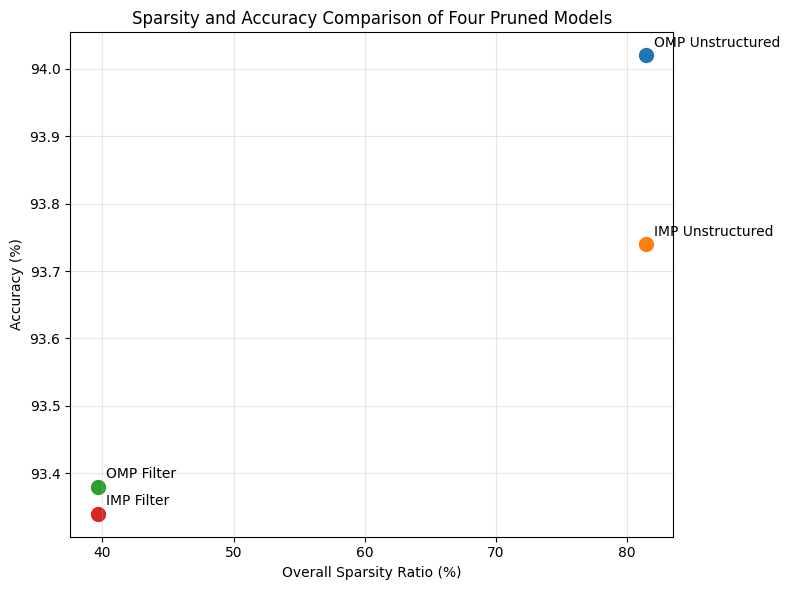

In [5]:
plt.figure(figsize=(8, 6))

for model_name, values in results.items():
    sparsity = values["sparsity"] * 100
    accuracy = values["accuracy"]

    plt.scatter(sparsity, accuracy, s=100)
    plt.annotate(
        model_name,
        (sparsity, accuracy),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Overall Sparsity Ratio (%)")
plt.ylabel("Accuracy (%)")
plt.title("Sparsity and Accuracy Comparison of Four Pruned Models")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("results/figure1_sparsity_accuracy.png", dpi=300)
plt.show()

In [6]:
model_dir = "./model"

model_files = {
    "OMP Unstructured": None,
    "IMP Unstructured": None,
    "OMP Filter": None,
    "IMP Filter": None
}

for file_name in os.listdir(model_dir):
    if file_name.startswith("Omp_unstructured_0.80_acc_"):
        model_files["OMP Unstructured"] = os.path.join(model_dir, file_name)

    elif file_name.startswith("Imp_unstructured_0.80_acc_"):
        model_files["IMP Unstructured"] = os.path.join(model_dir, file_name)

    elif file_name.startswith("Omp_filter_0.40_acc_"):
        model_files["OMP Filter"] = os.path.join(model_dir, file_name)

    elif file_name.startswith("Imp_filter_0.40_acc_"):
        model_files["IMP Filter"] = os.path.join(model_dir, file_name)

model_files

{'OMP Unstructured': './model/Omp_unstructured_0.80_acc_94.020.pt',
 'IMP Unstructured': './model/Imp_unstructured_0.80_acc_93.740.pt',
 'OMP Filter': './model/Omp_filter_0.40_acc_93.380.pt',
 'IMP Filter': './model/Imp_filter_0.40_acc_93.340.pt'}

In [7]:
def load_model(model_path):
    model = vgg13()

    state_dict = torch.load(
        model_path,
        map_location="cpu"
    )

    model.load_state_dict(state_dict)
    model.eval()

    return model

In [8]:
layer_name = "features.3.weight"

In [9]:
def get_mask(model, layer_name):
    weight = dict(model.named_parameters())[layer_name]

    weight_2d = weight.detach().cpu().numpy().reshape(
        weight.shape[0],
        -1
    )

    mask = (weight_2d != 0).astype(int)

    return mask

In [10]:
def plot_mask(model_path, model_name, figure_name):
    model = load_model(model_path)
    mask = get_mask(model, layer_name)

    plt.figure(figsize=(12, 6))

    plt.imshow(
        mask,
        aspect="auto",
        interpolation="nearest",
        cmap="binary"
    )

    plt.xlabel("Weights (Channels × Kernel Height × Kernel Width)")
    plt.ylabel("Filters")
    plt.title(f"{model_name} - Sparsity Mask of {layer_name}")

    plt.colorbar(
        ticks=[0, 1],
        label="0 = Pruned, 1 = Non-zero"
    )

    plt.tight_layout()
    plt.savefig(figure_name, dpi=300)
    plt.show()

/tmp/ipykernel_3580293/2028894269.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


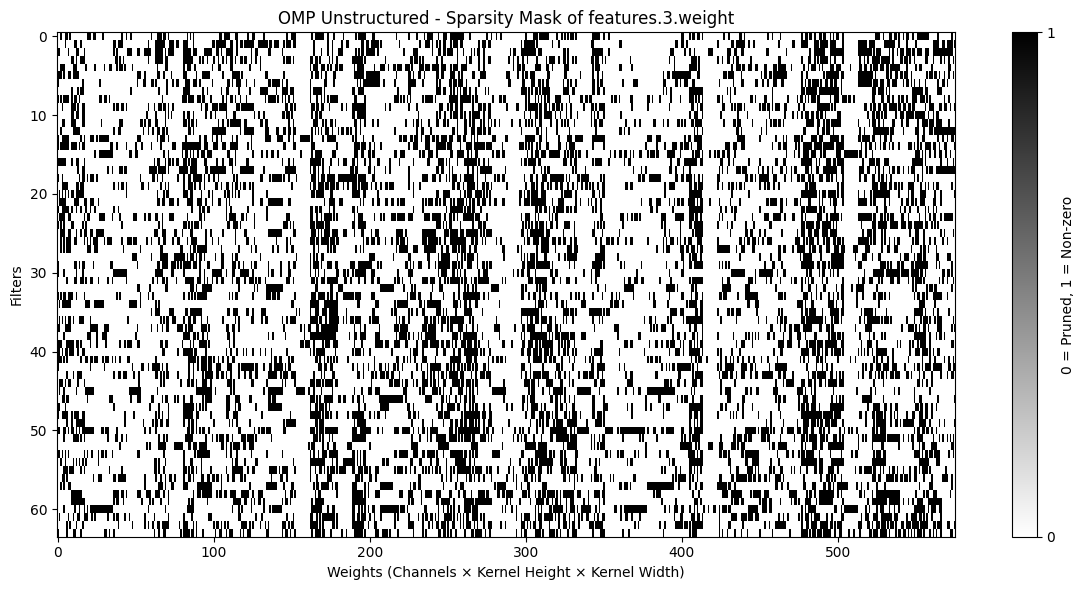

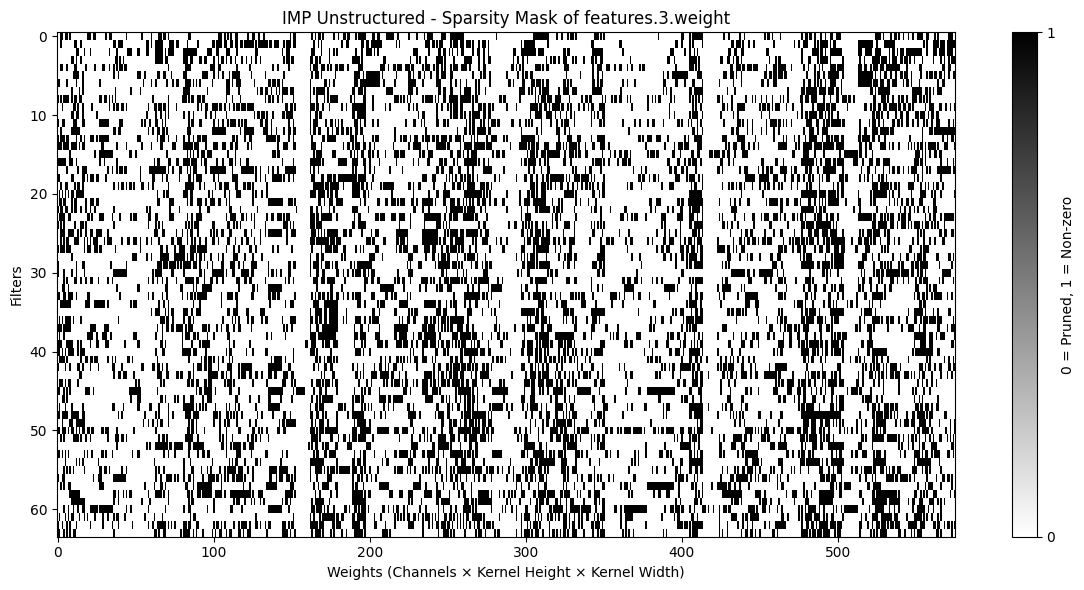

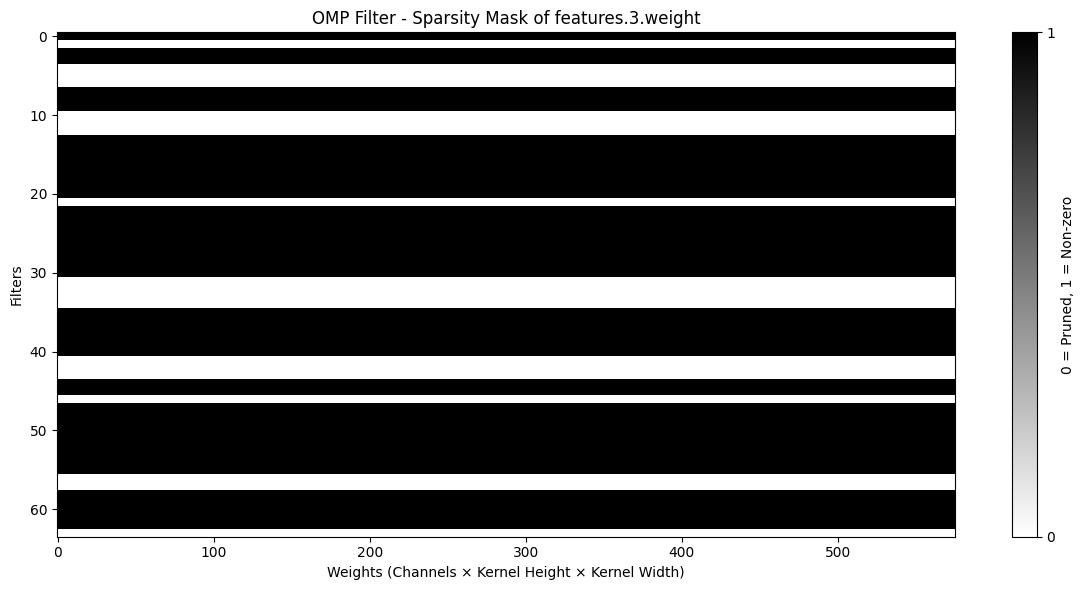

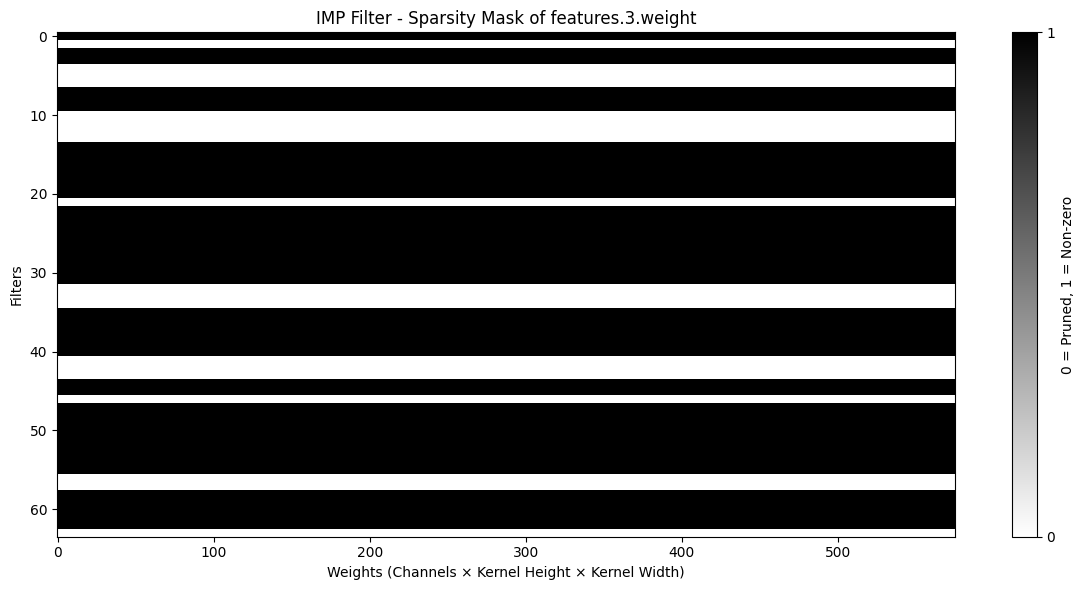

In [11]:
plot_mask(
    model_files["OMP Unstructured"],
    "OMP Unstructured",
    "results/figure2_omp_unstructured_mask.png"
)

plot_mask(
    model_files["IMP Unstructured"],
    "IMP Unstructured",
    "results/figure3_imp_unstructured_mask.png"
)

plot_mask(
    model_files["OMP Filter"],
    "OMP Filter",
    "results/figure4_omp_filter_mask.png"
)

plot_mask(
    model_files["IMP Filter"],
    "IMP Filter",
    "results/figure5_imp_filter_mask.png"
)